In [39]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#444',
    'axes.labelcolor': '#ccc',
    'axes.titlecolor': '#fff',
    'xtick.color': '#aaa',
    'ytick.color': '#aaa',
    'text.color': '#ccc',
    'grid.color': '#2a2d3a',
    'grid.linestyle': '--',
    'grid.alpha': 0.6,
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#444',
    'figure.titlesize': 14,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

COLORS = {
    'ASH_COATED_OSMIUM': '#00c9ff',
    'INTARIAN_PEPPER_ROOT': '#ff6b6b',
    'bid': '#00e676',
    'ask': '#ff5252',
    'mid': '#ffd740',
    'trade': '#ce93d8',
}

DAYS = [-2, -1, 0]
DATA_PATH = 'Data\\ROUND1\\prices_round_1_day_{}.csv'
TRADE_PATH = 'Data\\ROUND1\\trades_round_1_day_{}.csv'

print('Libraries loaded ✓')

Libraries loaded ✓


In [46]:
price_dfs, trade_dfs = [], []

for day in DAYS:
    p = pd.read_csv(DATA_PATH.format(day), sep=';')
    t = pd.read_csv(TRADE_PATH.format(day), sep=';')
    price_dfs.append(p)
    trade_dfs.append(t)

master_prices = pd.concat(price_dfs, ignore_index=True)
master_trades = pd.concat(trade_dfs, ignore_index=True)

PRODUCTS = prices['product'].unique().tolist()

prices = master_prices[~((master_prices['product'] == 'INTARIAN_PEPPER_ROOT') & (master_prices['mid_price'] == 0))]
prices = master_prices[~((master_prices['product'] == 'ASH_COATED_OSMIUM') & (master_prices['mid_price'] == 0))]
master_trades.head()

,timestamp,buyer,seller,symbol,currency,price,quantity
0,700,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9990.0,6
1,900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9998.0,2
2,1000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,9995.0,7
3,2500,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10011.0,8
4,4000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10007.0,7


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
40000,0,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10013.0,30.0,NaN,NaN,NaN,NaN,10013.0,0.0
40001,0,0,INTARIAN_PEPPER_ROOT,11991.0,19.0,NaN,NaN,NaN,NaN,12006.0,10.0,12009.0,19.0,NaN,NaN,11998.5,0.0
40002,0,100,INTARIAN_PEPPER_ROOT,11994.0,9.0,11991.0,23.0,NaN,NaN,12007.0,9.0,12010.0,23.0,NaN,NaN,12000.5,0.0
40003,0,100,ASH_COATED_OSMIUM,9995.0,13.0,NaN,NaN,NaN,NaN,10011.0,13.0,10013.0,30.0,NaN,NaN,10003.0,0.0
40004,0,200,INTARIAN_PEPPER_ROOT,11991.0,20.0,NaN,NaN,NaN,NaN,12007.0,11.0,12010.0,20.0,NaN,NaN,11999.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59990,0,999500,ASH_COATED_OSMIUM,10000.0,13.0,9997.0,28.0,NaN,NaN,10018.0,28.0,NaN,NaN,NaN,NaN,10009.0,0.0
59991,0,999500,INTARIAN_PEPPER_ROOT,12989.0,19.0,NaN,NaN,NaN,NaN,13006.0,12.0,NaN,NaN,NaN,NaN,12997.5,0.0
59992,0,999600,INTARIAN_PEPPER_ROOT,12993.0,8.0,NaN,NaN,NaN,NaN,13007.0,8.0,13010.0,25.0,NaN,NaN,13000.0,0.0
59993,0,999600,ASH_COATED_OSMIUM,10000.0,14.0,9997.0,27.0,NaN,NaN,10016.0,14.0,10018.0,27.0,NaN,NaN,10008.0,0.0


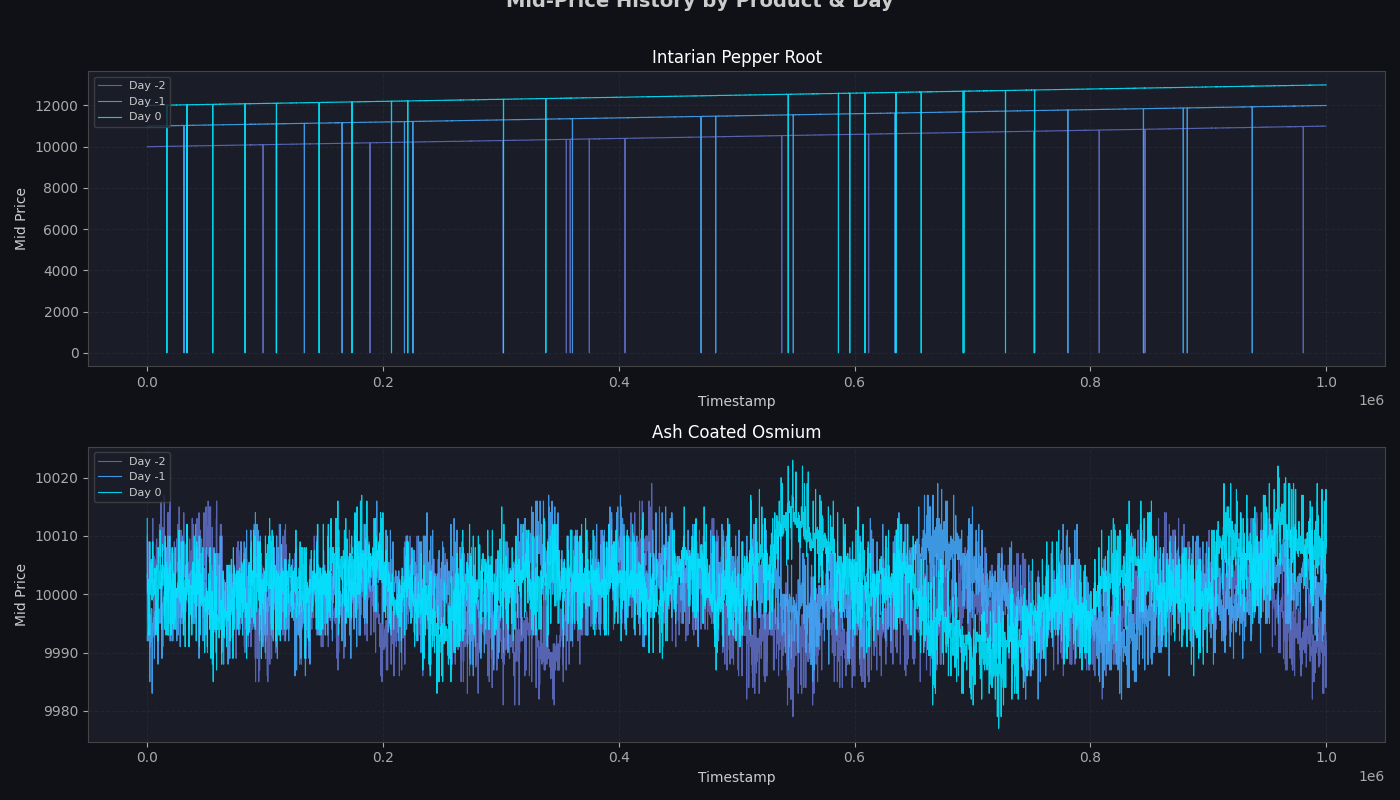

In [42]:
fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(14, 8), sharex=False)
fig.suptitle('Mid-Price History by Product & Day', fontsize=14, fontweight='bold', y=1.01)

day_colors = {-2: '#5c6bc0', -1: '#42a5f5', 0: '#00e5ff'}
day_labels = {-2: 'Day -2', -1: 'Day -1', 0: 'Day 0'}

for ax, product in zip(axes, PRODUCTS):
    sub = prices[prices['product'] == product]
    for day in DAYS:
        d = sub[sub['day'] == day].sort_values('timestamp')
        ax.plot(d['timestamp'], d['mid_price'],
                color=day_colors[day], lw=0.8, label=day_labels[day], alpha=0.9)
    ax.set_title(product.replace('_', ' ').title())
    ax.set_ylabel('Mid Price')
    ax.set_xlabel('Timestamp')
    ax.grid(True)
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('mid_price_history.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

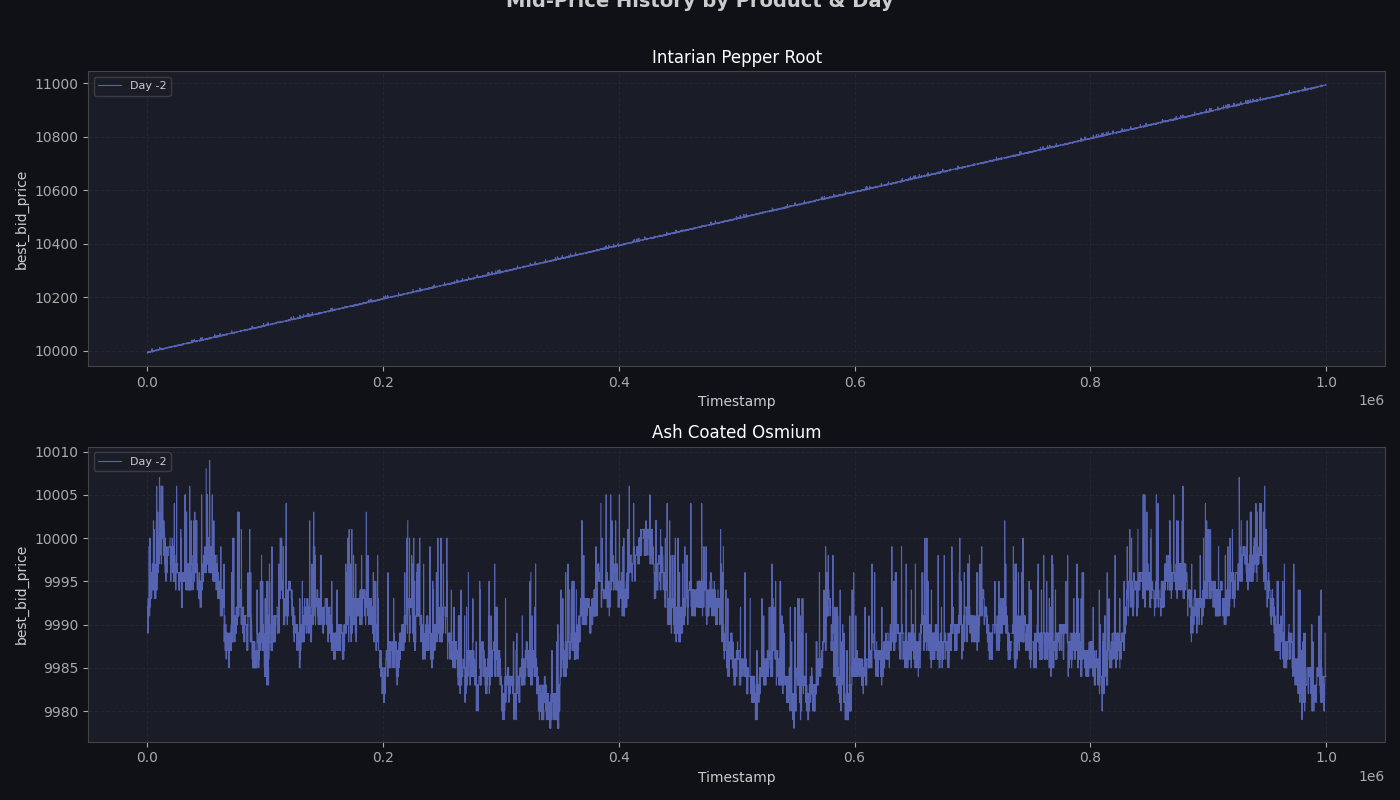

In [43]:
DAYS = [-2]
fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(14, 8), sharex=False)
fig.suptitle('Mid-Price History by Product & Day', fontsize=14, fontweight='bold', y=1.01)

day_colors = {-2: '#5c6bc0', -1: '#42a5f5', 0: '#00e5ff'}
day_labels = {-2: 'Day -2', -1: 'Day -1', 0: 'Day 0'}

for ax, product in zip(axes, PRODUCTS):
    sub = prices[prices['product'] == product]
    for day in DAYS:
        d = sub[sub['day'] == day].sort_values('timestamp')
        ax.plot(d['timestamp'], d['bid_price_1'],
                color=day_colors[day], lw=0.8, label=day_labels[day], alpha=0.9)
    ax.set_title(product.replace('_', ' ').title())
    ax.set_ylabel('best_bid_price')
    ax.set_xlabel('Timestamp')
    ax.grid(True)
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('bid_price_history.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [44]:
def get_daily_slopes(df):
    results = []
    # Grouping by day first, then product
    for (day, product), sub_df in df.groupby(['day', 'product']):
        if len(sub_df) > 1:
            # y = mx + b -> returns [slope, intercept]
            slope, _ = np.polyfit(sub_df['timestamp'], sub_df['mid_price'], 1)
            results.append({
                'day': day, 
                'product': product, 
                'daily_slope': slope
            })
    return pd.DataFrame(results)

daily_slopes_df = get_daily_slopes(prices)
print(daily_slopes_df)


def get_window_slope(df, day, product, start_ts, end_ts):
    # Filter for the specific day, product, and timestamp range
    mask = (df['day'] == day) & \
           (df['product'] == product) & \
           (df['timestamp'] >= start_ts) & \
           (df['timestamp'] <= end_ts)
    
    window_df = df[mask]
    
    if len(window_df) < 2:
        return None  # Need at least two points to form a slope
    
    # y = mx + b -> returns [slope, intercept]
    slope, _ = np.polyfit(window_df['timestamp'], window_df['mid_price'], 1)
    return slope

# Example usage:
slope = get_window_slope(prices, day=-2, product='INTARIAN_PEPPER_ROOT', start_ts=0, end_ts=5000)
print(f"Slope for window: {slope}")

   day               product   daily_slope
0   -2     ASH_COATED_OSMIUM -1.387399e-06
1   -2  INTARIAN_PEPPER_ROOT  1.001048e-03
2   -1     ASH_COATED_OSMIUM -8.815874e-07
3   -1  INTARIAN_PEPPER_ROOT  1.008554e-03
4    0     ASH_COATED_OSMIUM  1.547147e-06
5    0  INTARIAN_PEPPER_ROOT  1.032849e-03
Slope for window: 0.0009886877828048164


In [ ]:
def intarian_root_take(self, state: TradingState, historical_fair_price : float, orders : list[Order]) -> int:
        order_depth = state.order_depths['INTARIAN_PEPPER_ROOT']
        buy_orders = order_depth.buy_orders 
        sell_orders = order_depth.sell_orders 
        position = state.position.get('INTARIAN_PEPPER_ROOT', 0)

        fair_price = historical_fair_price

        for value in sell_orders:
            if value < fair_price:
                orders.append(Order("INTARIAN_PEPPER_ROOT", value, min(-sell_orders[value], 80 - position)))
        for value in buy_orders:
            if value > fair_price:
                    orders.append(Order("INTARIAN_PEPPER_ROOT", value, max(-buy_orders[value], 80 - position)))
    